In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms
import random


In [ ]:
## -- 시드 고정 --

random.seed(42)
np.random.seed(42)

In [ ]:

# --- [하이퍼파라미터 설정] ---

HIDDEN_NODES1 = 100
HIDDEN_NODES2 = 50
HIDDEN_NODES3 = 30
HIDDEN_NODES4 = 20
LR = 0.01
BATCH_SIZE = 100
EPOCHS = 20
ACTIVATION = 'ReLU' #

# 실험
OPTIMIZER = "SGD" # OR ADAM
INIT = "XAVIER" # OR HE
DROPOUT=True# OR True



In [ ]:

# --- [데이터 준비] ---
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [ ]:

# 텐서를 넘파이로 추출 후 전처리 (Flatten + 정규화)
x_all = full_train.data.numpy().astype(np.float32).reshape(60000, 784) / 255.0
t_all = np.eye(10)[full_train.targets.numpy()] # One-hot

x_test = test_dataset.data.numpy().astype(np.float32).reshape(10000, 784) / 255.0
t_test = np.eye(10)[test_dataset.targets.numpy()]

# --- [Train / Validation 분리] ---
indices = np.arange(60000)
np.random.shuffle(indices)

train_idx, val_idx = indices[:50000], indices[50000:]
x_train, t_train = x_all[train_idx], t_all[train_idx]
x_val, t_val = x_all[val_idx], t_all[val_idx]

print(f"Data ready: Train {x_train.shape}, Val {x_val.shape}, Test {x_test.shape}")


Data ready: Train (50000, 784), Val (10000, 784), Test (10000, 784)


In [ ]:
# 레이어 구현

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

def cross_entropy_error(y, t):
    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e-7)) / batch_size

class Relu:
    def __init__(self):
        self.mask = None
    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy(); out[self.mask] = 0
        return out
    def backward(self, dout):
        dout[self.mask] = 0
        return dout

class Affine:
    def __init__(self, W, b):
        self.W, self.b = W, b
        self.x, self.dW, self.db = None, None, None
    def forward(self, x):
        self.x = x
        return np.dot(self.x, self.W) + self.b
    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)
        return dx

class Dropout:
    def __init__(self, p=0.2):
        self.p = p; self.mask = None
    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.p
            return x * self.mask / (1.0 - self.p)
        return x
    def backward(self, dout):
        return dout * self.mask / (1.0 - self.p)

class SoftmaxWithLoss:
    def __init__(self):
        self.loss, self.y, self.t = None, None, None
    def forward(self, x, t):
        self.t = t; self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)
        return self.loss
    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        return (self.y - self.t) / batch_size


In [ ]:

# Optimizer
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2
        self.iter = 0; self.m = None; self.v = None
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val); self.v[key] = np.zeros_like(val)
        self.iter += 1
        lr_t = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)
        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

In [ ]:
# 모델 구현

# --- [모델 설계] ---
class MNIST_Net:
    def __init__(self, h1, h2, h3, h4, act_type):
        self.params = {}
        layers_size = [784, h1, h2, h3, h4, 10]

        # 가중치 초기화 (XAVIER / HE)
        for i in range(1, len(layers_size)):
            if INIT == "XAVIER":
                scale = np.sqrt(1.0 / layers_size[i-1])
            elif INIT == "HE":
                scale = np.sqrt(2.0 / layers_size[i-1])

            self.params[f'W{i}'] = scale * np.random.randn(layers_size[i-1], layers_size[i])
            self.params[f'b{i}'] = np.zeros(layers_size[i])

        # 계층 생성 (fc1~fc5 및 활성화, 드롭아웃)
        self.layers = []
        p_val = 0.2 if DROPOUT else 0.0

        for i in range(1, 5): # fc1 ~ fc4 + ReLU + Dropout
            self.layers.append(Affine(self.params[f'W{i}'], self.params[f'b{i}']))
            self.layers.append(Relu())
            self.layers.append(Dropout(p_val))

        self.layers.append(Affine(self.params['W5'], self.params['b5'])) # fc5
        self.last_layer = SoftmaxWithLoss()

    def predict(self, x, train_flg=False):
        for layer in self.layers:
            if isinstance(layer, Dropout):
                x = layer.forward(x, train_flg)
            else:
                x = layer.forward(x)
        return x

    def gradient(self, x, t):
        # forward
        loss = self.last_layer.forward(self.predict(x, train_flg=True), t)
        # backward
        dout = self.last_layer.backward(1)
        for layer in reversed(self.layers):
            dout = layer.backward(dout)

        # 가중치 기울기 추출
        grads = {}
        affine_layers = [l for l in self.layers if isinstance(l, Affine)]
        for i, layer in enumerate(affine_layers):
            grads[f'W{i+1}'] = layer.dW
            grads[f'b{i+1}'] = layer.db
        return grads, loss

# 모델 및 옵티마이저 선언 (파이토치와 동일한 흐름)
model = MNIST_Net(HIDDEN_NODES1, HIDDEN_NODES2, HIDDEN_NODES3, HIDDEN_NODES4, ACTIVATION)

if OPTIMIZER == "SGD":
    optimizer = SGD(lr=LR)
elif OPTIMIZER == "ADAM":
    optimizer = Adam(lr=LR)

In [ ]:
train_losses = []
val_accuracies = []
train_accuracies = []

for epoch in range(EPOCHS):
    # 데이터 셔플
    idx = np.random.permutation(x_train.shape[0])
    x_train_sh, t_train_sh = x_train[idx], t_train[idx]

    total_loss = 0
    train_acc_cnt = 0

    # --- [Train 루프] ---
    for i in range(0, x_train.shape[0], BATCH_SIZE):
        x_batch = x_train_sh[i:i+BATCH_SIZE]
        t_batch = t_train_sh[i:i+BATCH_SIZE]

        # zero_grad + backward 역할
        grads, loss = model.gradient(x_batch, t_batch)

        # optimizer.step() 역할
        optimizer.update(model.params, grads)

        total_loss += loss * x_batch.shape[0]

        # 정확도 계산 (predicted == labels)
        y_pred = model.predict(x_batch, train_flg=False)
        train_acc_cnt += np.sum(np.argmax(y_pred, axis=1) == np.argmax(t_batch, axis=1))

    avg_loss = total_loss / x_train.shape[0]
    train_losses.append(avg_loss)

    avg_train_acc = 100 * train_acc_cnt / x_train.shape[0]
    train_accuracies.append(avg_train_acc)

    # --- [Validation 루프] ---
    val_correct = 0
    for i in range(0, x_val.shape[0], BATCH_SIZE):
        x_v_batch = x_val[i:i+BATCH_SIZE]
        t_v_batch = t_val[i:i+BATCH_SIZE]

        y_val_pred = model.predict(x_v_batch, train_flg=False)
        val_correct += np.sum(np.argmax(y_val_pred, axis=1) == np.argmax(t_v_batch, axis=1))

    val_acc = 100 * val_correct / x_val.shape[0]
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

Epoch [1/20] Loss: 2.2026, Train Acc: 28.40%, Val Acc: 39.17%
Epoch [2/20] Loss: 1.8850, Train Acc: 40.49%, Val Acc: 44.83%
Epoch [3/20] Loss: 1.5707, Train Acc: 59.55%, Val Acc: 69.81%
Epoch [4/20] Loss: 1.2325, Train Acc: 73.36%, Val Acc: 76.09%
Epoch [5/20] Loss: 1.0257, Train Acc: 79.26%, Val Acc: 80.69%
Epoch [6/20] Loss: 0.8859, Train Acc: 83.68%, Val Acc: 84.82%
Epoch [7/20] Loss: 0.7842, Train Acc: 86.72%, Val Acc: 87.44%
Epoch [8/20] Loss: 0.7009, Train Acc: 89.41%, Val Acc: 89.63%
Epoch [9/20] Loss: 0.6337, Train Acc: 91.07%, Val Acc: 90.98%
Epoch [10/20] Loss: 0.5770, Train Acc: 91.98%, Val Acc: 91.78%
Epoch [11/20] Loss: 0.5343, Train Acc: 92.66%, Val Acc: 92.50%
Epoch [12/20] Loss: 0.5029, Train Acc: 93.20%, Val Acc: 92.75%
Epoch [13/20] Loss: 0.4757, Train Acc: 93.71%, Val Acc: 93.39%
Epoch [14/20] Loss: 0.4519, Train Acc: 94.08%, Val Acc: 93.70%
Epoch [15/20] Loss: 0.4268, Train Acc: 94.47%, Val Acc: 93.91%
Epoch [16/20] Loss: 0.4083, Train Acc: 94.79%, Val Acc: 94.28%
E

In [ ]:
# --- [최종 Test Accuracy] ---
correct = 0

for i in range(0, x_test.shape[0], BATCH_SIZE):
    x_batch = x_test[i:i+BATCH_SIZE]
    t_batch = t_test[i:i+BATCH_SIZE] # 원-핫 인코딩 상태

    # 예측값 산출
    outputs = model.predict(x_batch, train_flg=False)

    # np.argmax를 통해 클래스 인덱스 추출
    predicted = np.argmax(outputs, axis=1)
    actual = np.argmax(t_batch, axis=1)

    correct += np.sum(predicted == actual)

print(f"\n최종 Test Accuracy: {100 * correct / x_test.shape[0]:.2f}%")


최종 Test Accuracy: 94.92%


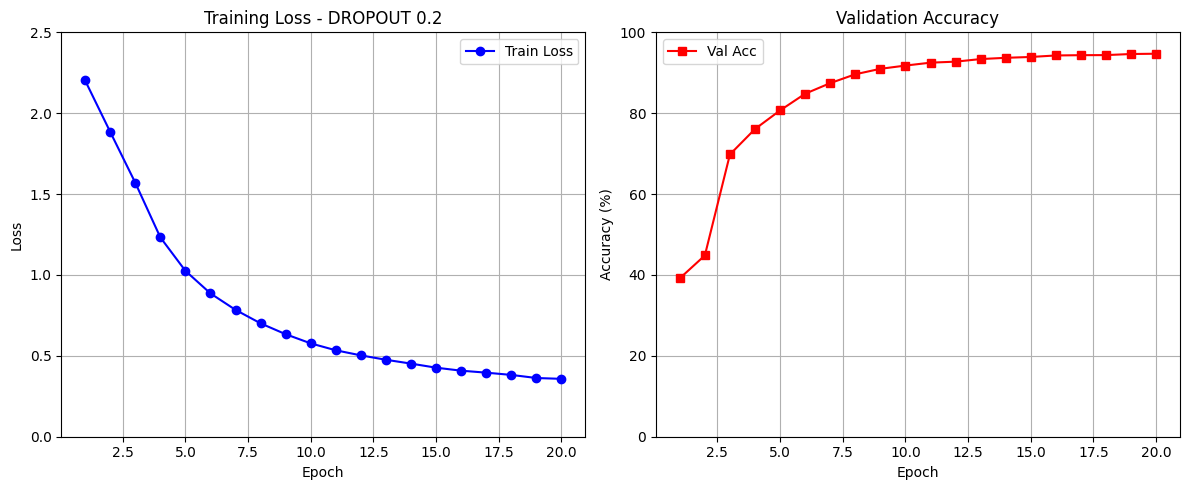

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- 왼쪽: Training Loss (스케일 0 ~ 2.5 고정!) ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='blue', label='Train Loss')
plt.title(f'Training Loss - DROPOUT 0.2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 2.5)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy (스케일 0 ~ 100 고정) ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='red', label='Val Acc')
plt.title(f'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()